<h1>Importing libraries<h1>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mp
%matplotlib inline
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split

<h1>Data Collection<h1>

In [3]:
sc=pd.read_csv("D:\suicide in india.csv")
sc.head()

,State,Year,Type_code,Type,Gender,Age_group,Total
0,A & N Islands,2001,Causes,Illness (Aids/STD),Female,0-14,0
1,A & N Islands,2001,Causes,Bankruptcy or Sudden change in Economic,Female,0-14,0
2,A & N Islands,2001,Causes,Cancellation/Non-Settlement of Marriage,Female,0-14,0
3,A & N Islands,2001,Causes,Physical Abuse (Rape/Incest Etc.),Female,0-14,0
4,A & N Islands,2001,Causes,Dowry Dispute,Female,0-14,0


In [4]:
sc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237519 entries, 0 to 237518
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   State      237519 non-null  object
 1   Year       237519 non-null  int64 
 2   Type_code  237519 non-null  object
 3   Type       237519 non-null  object
 4   Gender     237519 non-null  object
 5   Age_group  237519 non-null  object
 6   Total      237519 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 12.7+ MB


In [5]:
sc.describe()

,Year,Total
count,237519.000000,237519.000000
mean,2006.500448,55.034477
std,3.452240,792.749038
min,2001.000000,0.000000
25%,2004.000000,0.000000
50%,2007.000000,0.000000
75%,2010.000000,6.000000
max,2012.000000,63343.000000


In [9]:
sc.shape

(109200, 7)

In [10]:
sc.count()

State        109200
Year         109200
Type_code    109200
Type         109200
Gender       109200
Age_group    109200
Total        109200
dtype: int64

In [13]:
sc.columns

Index(['State', 'Year', 'Type_code', 'Type', 'Gender', 'Age_group',
       'Suicide_counts'],
      dtype='object')

<h1>Data Pre-processing<h1>

In [6]:
sc=sc[sc['Type_code']!='Professional_Profile'].dropna()
sc.Type_code.value_counts()

Causes              109200
Means_adopted        67200
Education_Status      7296
Social_Status         4560
Name: Type_code, dtype: int64

In [7]:
sc=sc[sc['Type_code']!='Means_adopted'].dropna()
sc.Type_code.value_counts()

Causes              109200
Education_Status      7296
Social_Status         4560
Name: Type_code, dtype: int64

In [8]:
sc=sc[sc['Age_group']!='0-100+'].dropna()
sc.Age_group.value_counts()

0-14     21840
15-29    21840
30-44    21840
45-59    21840
60+      21840
Name: Age_group, dtype: int64

In [11]:
sc=sc.rename(columns={'Total':'Suicide_counts'})
sc.head()

,State,Year,Type_code,Type,Gender,Age_group,Suicide_counts
0,A & N Islands,2001,Causes,Illness (Aids/STD),Female,0-14,0
1,A & N Islands,2001,Causes,Bankruptcy or Sudden change in Economic,Female,0-14,0
2,A & N Islands,2001,Causes,Cancellation/Non-Settlement of Marriage,Female,0-14,0
3,A & N Islands,2001,Causes,Physical Abuse (Rape/Incest Etc.),Female,0-14,0
4,A & N Islands,2001,Causes,Dowry Dispute,Female,0-14,0


In [12]:
sc=sc.dropna(how='any')
sc

,State,Year,Type_code,Type,Gender,Age_group,Suicide_counts
0,A & N Islands,2001,Causes,Illness (Aids/STD),Female,0-14,0
1,A & N Islands,2001,Causes,Bankruptcy or Sudden change in Economic,Female,0-14,0
2,A & N Islands,2001,Causes,Cancellation/Non-Settlement of Marriage,Female,0-14,0
3,A & N Islands,2001,Causes,Physical Abuse (Rape/Incest Etc.),Female,0-14,0
4,A & N Islands,2001,Causes,Dowry Dispute,Female,0-14,0
...,...,...,...,...,...,...,...
237218,West Bengal,2012,Causes,Drug Abuse/Addiction,Male,60+,0
237219,West Bengal,2012,Causes,Not having Children(Barrenness/Impotency,Male,60+,0
237220,West Bengal,2012,Causes,Poverty,Male,60+,0
237221,West Bengal,2012,Causes,Family Problems,Male,60+,0


In [14]:
sc.head()

,State,Year,Type_code,Type,Gender,Age_group,Suicide_counts
0,A & N Islands,2001,Causes,Illness (Aids/STD),Female,0-14,0
1,A & N Islands,2001,Causes,Bankruptcy or Sudden change in Economic,Female,0-14,0
2,A & N Islands,2001,Causes,Cancellation/Non-Settlement of Marriage,Female,0-14,0
3,A & N Islands,2001,Causes,Physical Abuse (Rape/Incest Etc.),Female,0-14,0
4,A & N Islands,2001,Causes,Dowry Dispute,Female,0-14,0


In [15]:
sc.isnull().sum()

State             0
Year              0
Type_code         0
Type              0
Gender            0
Age_group         0
Suicide_counts    0
dtype: int64

In [16]:
sc.State.value_counts()

A & N Islands        3120
Puducherry           3120
Maharashtra          3120
Manipur              3120
Meghalaya            3120
Mizoram              3120
Nagaland             3120
Odisha               3120
Punjab               3120
Lakshadweep          3120
Rajasthan            3120
Sikkim               3120
Tamil Nadu           3120
Tripura              3120
Uttar Pradesh        3120
Uttarakhand          3120
Madhya Pradesh       3120
Kerala               3120
Andhra Pradesh       3120
Daman & Diu          3120
Arunachal Pradesh    3120
Assam                3120
Bihar                3120
Chandigarh           3120
Chhattisgarh         3120
D & N Haveli         3120
Delhi (Ut)           3120
Karnataka            3120
Goa                  3120
Gujarat              3120
Haryana              3120
Himachal Pradesh     3120
Jammu & Kashmir      3120
Jharkhand            3120
West Bengal          3120
Name: State, dtype: int64

In [17]:
sc.Gender.value_counts()

Female    54600
Male      54600
Name: Gender, dtype: int64

In [14]:
duplicate_row=sc[sc.duplicated()]
print('NO of duplicate rows: ',duplicate_row.shape[0])

NO of duplicate rows:  0


In [19]:
sc.tail()

,State,Year,Type_code,Type,Gender,Age_group,Suicide_counts
237218,West Bengal,2012,Causes,Drug Abuse/Addiction,Male,60+,0
237219,West Bengal,2012,Causes,Not having Children(Barrenness/Impotency,Male,60+,0
237220,West Bengal,2012,Causes,Poverty,Male,60+,0
237221,West Bengal,2012,Causes,Family Problems,Male,60+,0
237222,West Bengal,2012,Causes,Insanity/Mental Illness,Male,60+,0


In [15]:
type_code=sc.Type_code.unique()
print('Number of type code',len(type_code))
type_code

Number of type code 1


array(['Causes'], dtype=object)

In [16]:
state=sc.State.unique()
print('Number of states: ',len(state))
state

Number of states:  35


array(['A & N Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam',
       'Bihar', 'Chandigarh', 'Chhattisgarh', 'D & N Haveli',
       'Daman & Diu', 'Delhi (Ut)', 'Goa', 'Gujarat', 'Haryana',
       'Himachal Pradesh', 'Jammu & Kashmir', 'Jharkhand', 'Karnataka',
       'Kerala', 'Lakshadweep', 'Madhya Pradesh', 'Maharashtra',
       'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha',
       'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu',
       'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal'],
      dtype=object)

<h1>Data Visualization<h1>

In [17]:
numerical_data = sc.select_dtypes(include='number')
num_cols = numerical_data.columns
print("Numerical columns: ", num_cols)

Numerical columns:  Index(['Year', 'Suicide_counts'], dtype='object')


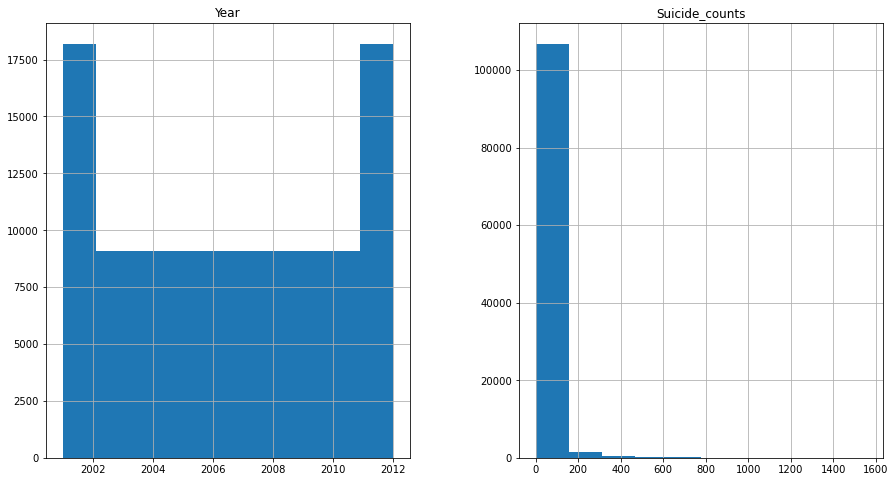

In [18]:
sc[num_cols].hist(figsize=(15, 8))
mp.show()

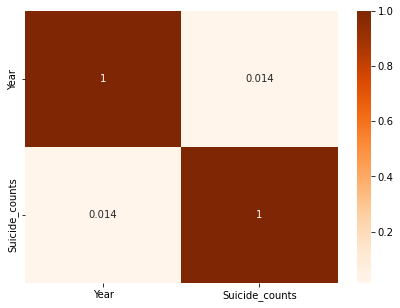

In [19]:
mp.figure(figsize=(7,5))
sns.heatmap(sc.corr(), annot=True, cmap='Oranges')
mp.show()

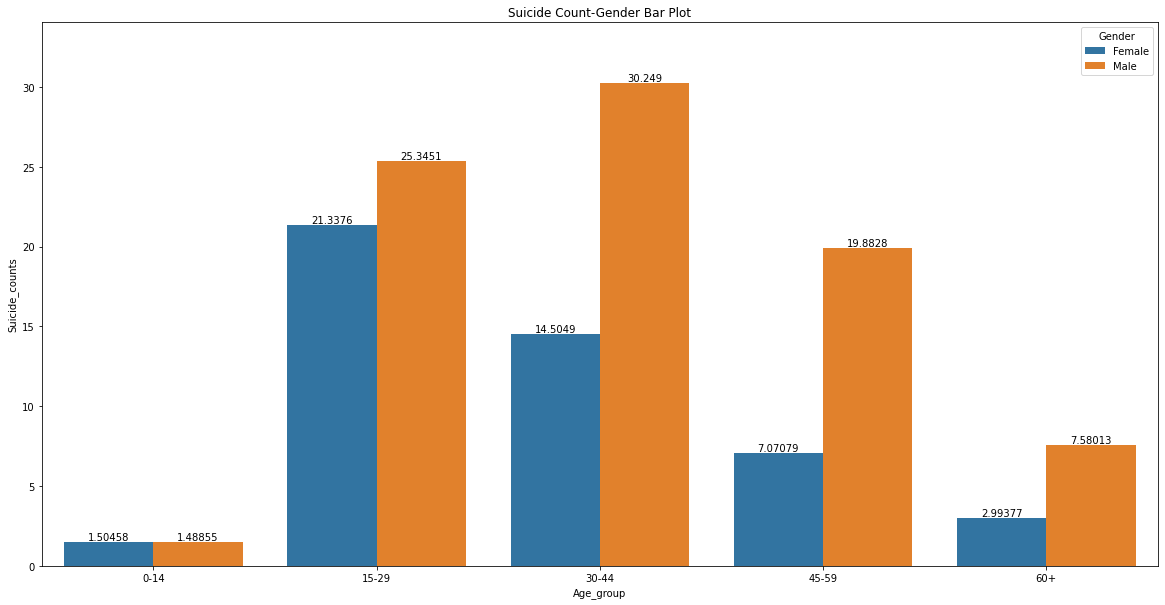

In [20]:
mp.figure(figsize=(20,10))
value=sns.barplot(x = "Age_group", y = "Suicide_counts", hue = "Gender", data = sc,errwidth=0)
for k in value.containers:
    value.bar_label(k,)
mp.title('Suicide Count-Gender Bar Plot')
mp.show()

In [21]:
sc1 = pd.pivot_table(sc, values='Suicide_counts', index=['State'],
                     aggfunc=np.sum, fill_value=0)
sc1

,Suicide_counts
State,
A & N Islands,1623
Andhra Pradesh,162820
Arunachal Pradesh,1328
Assam,34469
Bihar,9245
Chandigarh,1034
Chhattisgarh,60495
D & N Haveli,686
Daman & Diu,279


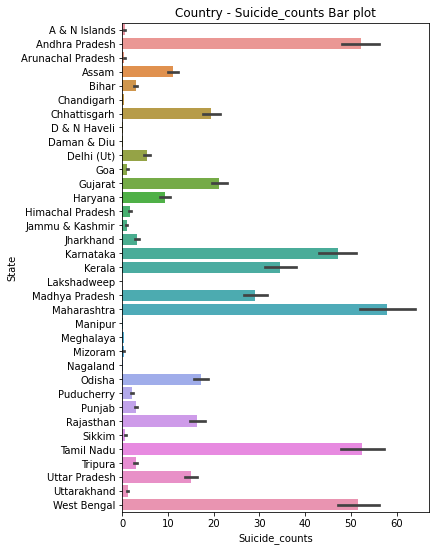

In [28]:
mp.figure(figsize=(5.5,9))
sns.barplot(x = sc["Suicide_counts"], y =sc["State"], data = sc1)
mp.title('Country - Suicide_counts Bar plot')
mp.show()

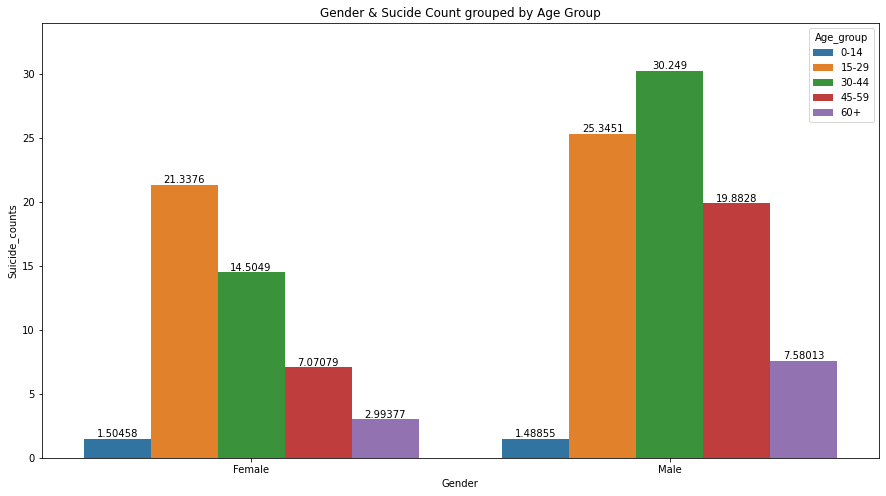

In [29]:
mp.figure(figsize=(15,8))
val=sns.barplot(x=sc["Gender"], y=sc["Suicide_counts"], hue=sc["Age_group"], data=sc,errwidth=0)
for i in val.containers:
    val.bar_label(i,)    
mp.title('Gender & Sucide Count grouped by Age Group')
mp.show()

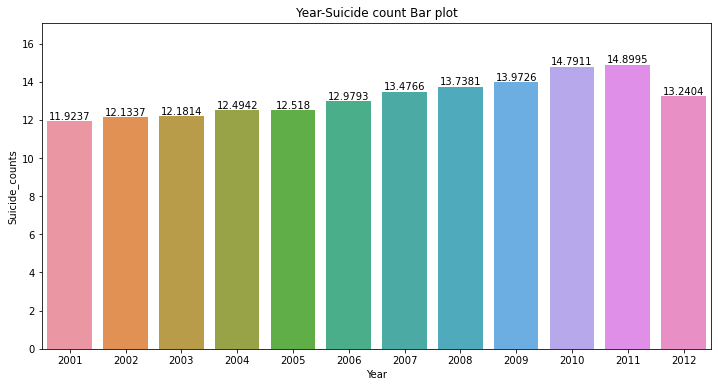

In [30]:
mp.figure(figsize=(12,6))
by_age=sns.barplot(x=sc['Year'],y=sc['Suicide_counts'],errwidth=0)
for i in by_age.containers:
    by_age.bar_label(i,) 
mp.title('Year-Suicide count Bar plot')
mp.show()

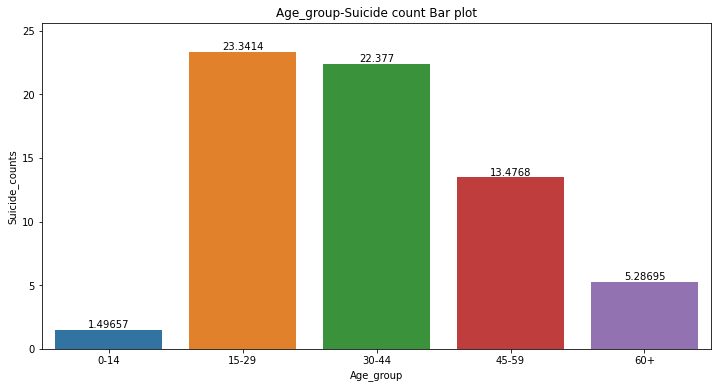

In [31]:
mp.figure(figsize=(12,6))
by_age=sns.barplot(x=sc['Age_group'],y=sc['Suicide_counts'],errwidth=0)
for i in by_age.containers:
    by_age.bar_label(i,) 
mp.title('Age_group-Suicide count Bar plot')
mp.show()

<AxesSubplot:xlabel='Year'>

<Figure size 720x504 with 0 Axes>

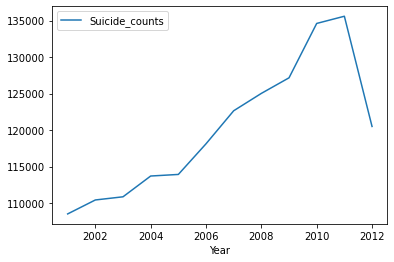

In [32]:
mp.figure(figsize=(10,7))
sc[['Year','Suicide_counts']].groupby(['Year']).sum().plot()

mp.figure(figsize=(30,20))
by_age=sns.barplot(x=sc['Suicide_counts'],y=sc['Type'])
mp.title('Type-Suicide count Bar plot')

Text(0.5, 1.0, 'Type-Suicide count Bar plot')

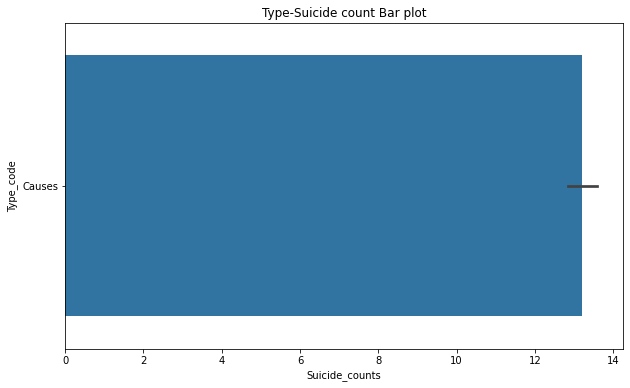

In [33]:
mp.figure(figsize=(10,6))
by_age=sns.barplot(x=sc['Suicide_counts'],y=sc['Type_code'])
mp.title('Type-Suicide count Bar plot')

In [34]:
types=sc.Type.unique()
print('Number of types',len(types))
types

Number of types 28


array(['Illness (Aids/STD)', 'Bankruptcy or Sudden change in Economic',
       'Cancellation/Non-Settlement of Marriage',
       'Physical Abuse (Rape/Incest Etc.)', 'Dowry Dispute',
       'Family Problems', 'Ideological Causes/Hero Worshipping',
       'Other Prolonged Illness', 'Property Dispute',
       'Fall in Social Reputation', 'Illegitimate Pregnancy',
       'Failure in Examination', 'Insanity/Mental Illness',
       'Love Affairs', 'Professional/Career Problem', 'Divorce',
       'Drug Abuse/Addiction', 'Not having Children(Barrenness/Impotency',
       'Causes Not known', 'Unemployment',
       'Other Causes (Please Specity)', 'Poverty', 'Death of Dear Person',
       'Cancer', 'Suspected/Illicit Relation', 'Paralysis',
       'Bankruptcy or Sudden change in Economic Status',
       'Not having Children (Barrenness/Impotency'], dtype=object)

In [35]:
sc1 = pd.pivot_table(sc, values='Suicide_counts', index=['Type'],
                     aggfunc=np.sum, fill_value=0)
sc1

,Suicide_counts
Type,
Bankruptcy or Sudden change in Economic,32755
Bankruptcy or Sudden change in Economic Status,2655
Cancellation/Non-Settlement of Marriage,11296
Cancer,9058
Causes Not known,237069
Death of Dear Person,10321
Divorce,4133
Dowry Dispute,31970
Drug Abuse/Addiction,30046


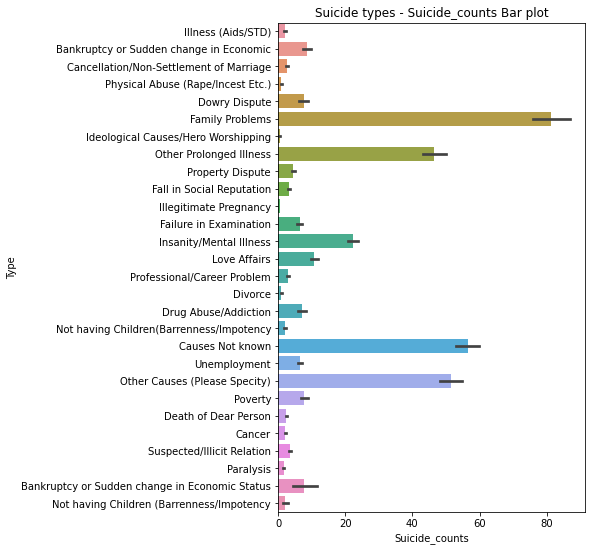

In [31]:
mp.figure(figsize=(5.5,9))
sns.barplot(x = sc["Suicide_counts"], y =sc["Type"], data = sc1)
mp.title('Suicide types - Suicide_counts Bar plot')
mp.show()

In [37]:
sc

,State,Year,Type_code,Type,Gender,Age_group,Suicide_counts
0,A & N Islands,2001,Causes,Illness (Aids/STD),Female,0-14,0
1,A & N Islands,2001,Causes,Bankruptcy or Sudden change in Economic,Female,0-14,0
2,A & N Islands,2001,Causes,Cancellation/Non-Settlement of Marriage,Female,0-14,0
3,A & N Islands,2001,Causes,Physical Abuse (Rape/Incest Etc.),Female,0-14,0
4,A & N Islands,2001,Causes,Dowry Dispute,Female,0-14,0
...,...,...,...,...,...,...,...
237218,West Bengal,2012,Causes,Drug Abuse/Addiction,Male,60+,0
237219,West Bengal,2012,Causes,Not having Children(Barrenness/Impotency,Male,60+,0
237220,West Bengal,2012,Causes,Poverty,Male,60+,0
237221,West Bengal,2012,Causes,Family Problems,Male,60+,0


In [42]:
import matplotlib.pyplot as plt
import scipy.stats as stats
def diagnostic_plot(data, col):
    fig = plt.figure(figsize=(20, 5))
    fig.subplots_adjust(right=1.5)
    
    plt.subplot(1, 3, 1)
    sns.distplot(data[col], kde=True, color='pink')
    plt.title('Histogram')
    
    plt.subplot(1, 3, 2)
    stats.probplot(data[col], dist='norm', fit=True, plot=plt)
    plt.title('Q-Q Plot')
    
    plt.subplot(1, 3, 3)
    sns.boxplot(data[col],color='pink')
    plt.title('Q-Q Plot')
    
    plt.show()

C:\Users\piyus\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).

C:\Users\piyus\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning:

Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



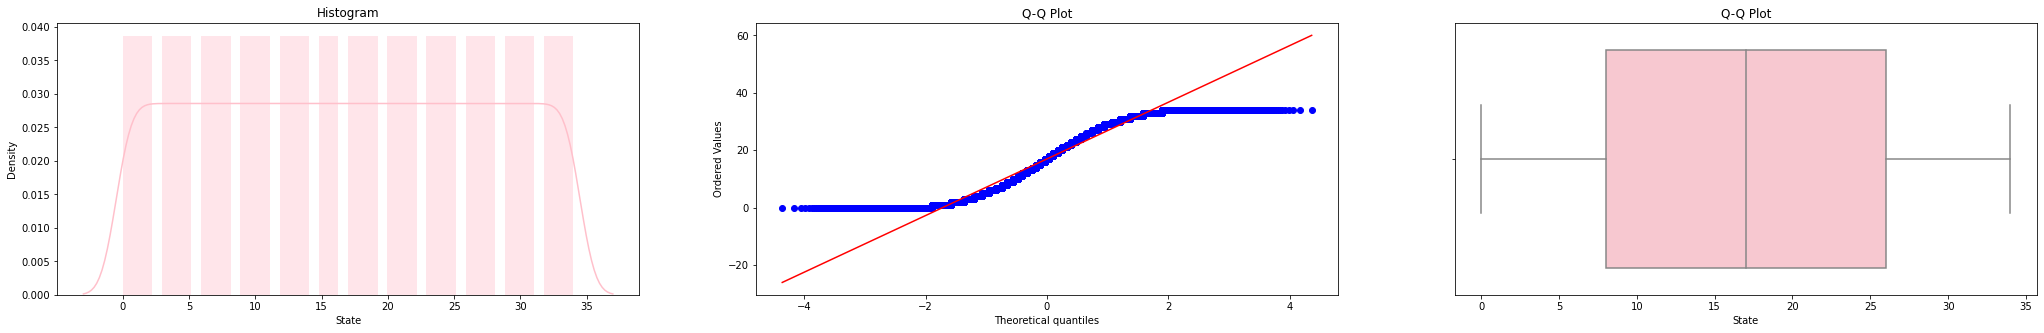

C:\Users\piyus\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).

C:\Users\piyus\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning:

Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



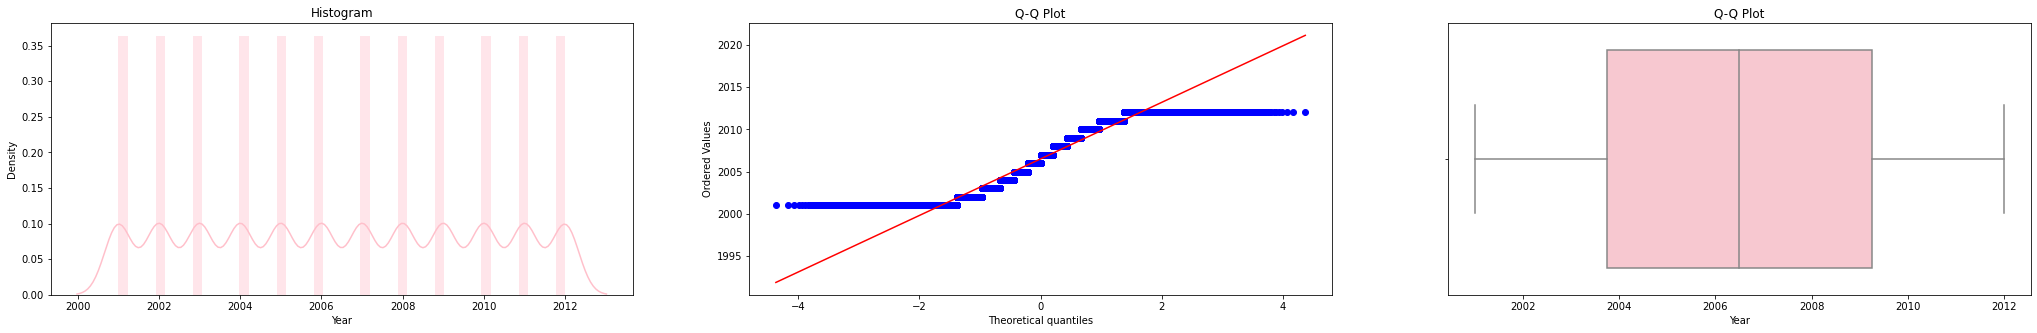

C:\Users\piyus\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).

C:\Users\piyus\anaconda3\lib\site-packages\seaborn\distributions.py:316: UserWarning:

Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.

C:\Users\piyus\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning:

Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



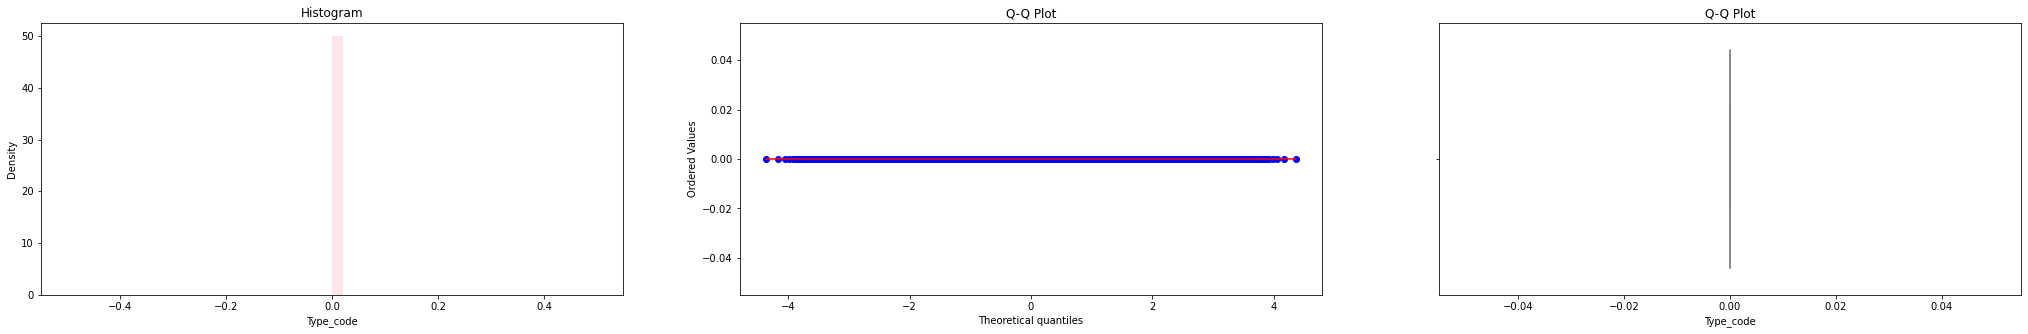

C:\Users\piyus\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).

C:\Users\piyus\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning:

Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



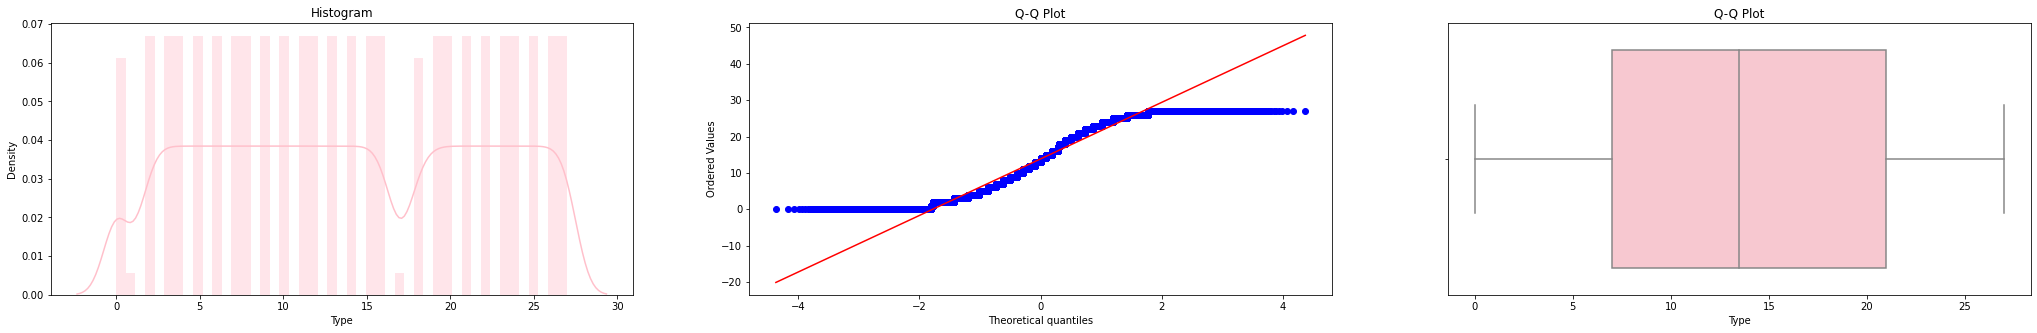

C:\Users\piyus\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).

C:\Users\piyus\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning:

Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



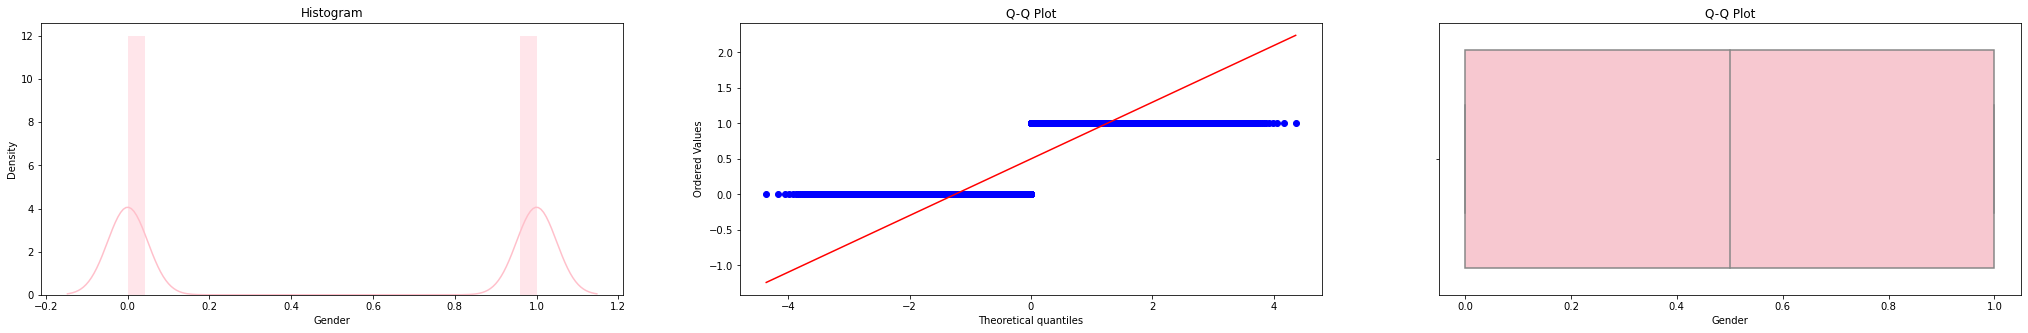

C:\Users\piyus\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).

C:\Users\piyus\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning:

Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



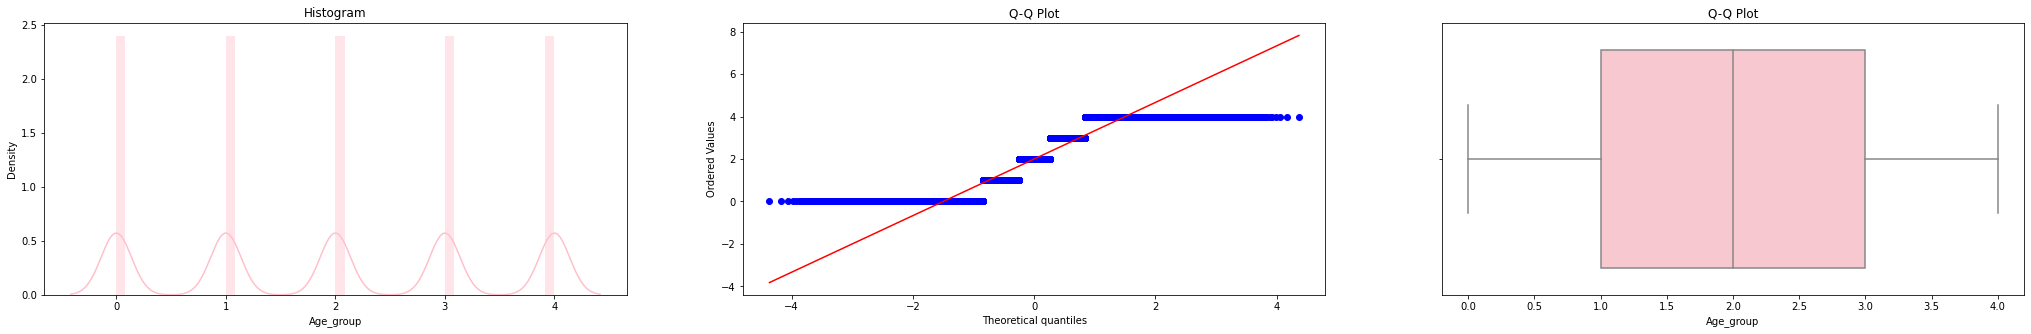

C:\Users\piyus\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).

C:\Users\piyus\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning:

Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



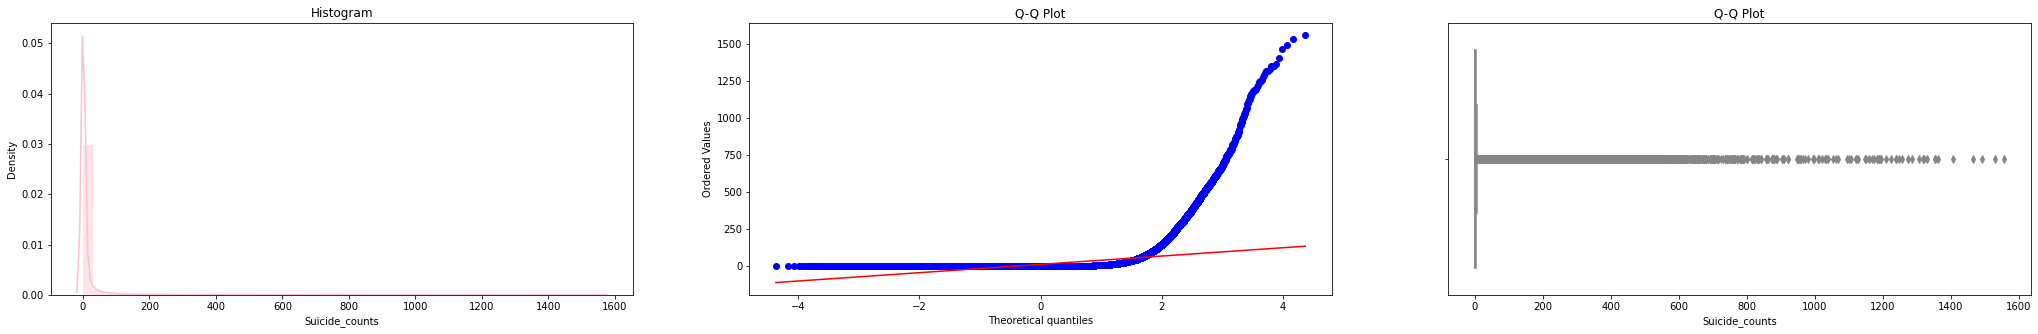

In [43]:
for col in sc.columns:
    diagnostic_plot(sc, col)

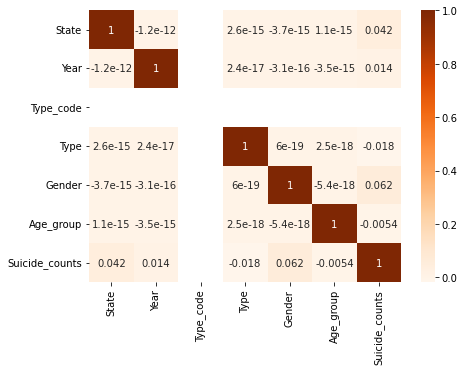

In [44]:
mp.figure(figsize=(7,5))
sns.heatmap(sc.corr(), annot=True, cmap='Oranges')
mp.show()

<h1>Feature Engineering and Label Encoding<h1>

In [38]:
cat_cols=[feature for feature in sc.columns if sc[feature].dtype=='O']
print(cat_cols)

['State', 'Type_code', 'Type', 'Gender', 'Age_group']


In [39]:
from sklearn.preprocessing import LabelEncoder
labelencoder=LabelEncoder()

In [40]:
for feature in cat_cols:
    sc[feature]=labelencoder.fit_transform(sc[feature])

In [41]:
sc['Type'].unique()

array([14,  0,  2, 22,  7, 11, 12, 20, 25, 10, 13,  9, 15, 16, 24,  6,  8,
       18,  4, 27, 19, 23,  5,  3, 26, 21,  1, 17])

In [45]:
features=[feature for feature in sc.columns if feature=='Suicide_counts']

In [46]:
Q1 = sc[features].quantile(0.10)
Q3 = sc[features].quantile(0.90)
IQR = Q3 - Q1
print(IQR)

Suicide_counts    20.0
dtype: float64


In [47]:
sc = sc[~((sc<(Q1-1.5*IQR))|(sc>(Q3+1.5*IQR))).any(axis=1)]
print("No. of rows remaining: ", sc.shape[0])

No. of rows remaining:  103176


C:\Users\piyus\AppData\Local\Temp\ipykernel_1192\615887565.py:1: FutureWarning:

Automatic reindexing on DataFrame vs Series comparisons is deprecated and will raise ValueError in a future version. Do `left, right = left.align(right, axis=1, copy=False)` before e.g. `left == right`



<h1>Model Training<h1>

<h4>Split the data<h4>

In [48]:
x = sc.iloc[:,:6]
y = sc.iloc[:,6:]
x

,State,Year,Type_code,Type,Gender,Age_group
0,0,2001,0,14,0,0
1,0,2001,0,0,0,0
2,0,2001,0,2,0,0
3,0,2001,0,22,0,0
4,0,2001,0,7,0,0
...,...,...,...,...,...,...
237218,34,2012,0,8,1,4
237219,34,2012,0,18,1,4
237220,34,2012,0,23,1,4
237221,34,2012,0,11,1,4


In [49]:
x.drop('Type', inplace=True, axis=1)

In [50]:
y['Suicide_counts'].unique()

array([ 0,  1,  8,  6,  5,  2,  4,  3,  9, 10, 11,  7, 13, 15, 20, 16, 12,
       14, 17, 48, 35, 47, 40, 23, 44, 21, 36, 18, 30, 31, 39, 22, 27, 41,
       19, 42, 25, 28, 33, 24, 43, 26, 50, 32, 29, 46, 38, 34, 37, 49, 45],
      dtype=int64)

In [51]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [52]:
print("X_train:",x_train.shape)
print("X_test:",x_test.shape)
print("Y_train:",y_train.shape)
print("Y_test:",y_test.shape)

X_train: (82540, 5)
X_test: (20636, 5)
Y_train: (82540, 1)
Y_test: (20636, 1)


In [53]:
x_train

,State,Year,Type_code,Gender,Age_group
1283,0,2003,0,0,3
113994,16,2011,0,1,3
99912,14,2010,0,1,4
92008,13,2008,0,0,4
18708,2,2010,0,1,3
...,...,...,...,...,...
48519,7,2003,0,0,2
103223,15,2004,0,0,3
96301,14,2004,0,0,0
98163,14,2007,0,1,3


In [54]:
x_test

,State,Year,Type_code,Gender,Age_group
195985,29,2001,0,1,0
185889,27,2007,0,0,2
191111,28,2004,0,1,4
91813,13,2008,0,1,0
128530,19,2001,0,1,2
...,...,...,...,...,...
59202,8,2010,0,0,3
158384,23,2006,0,0,3
157764,23,2005,0,1,1
21544,3,2003,0,1,3


<h1>Model Selection<h1>

In [57]:
from sklearn.ensemble import RandomForestRegressor

In [67]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV


# Create a Random Forest Regressor object
rf = RandomForestRegressor(n_estimators=500, max_depth=50, min_samples_split=50,
    min_samples_leaf=10)


rf.fit(x_train, y_train.values.ravel())

RandomForestRegressor(max_depth=50, min_samples_leaf=10, min_samples_split=50,
                      n_estimators=500)

<h1>Model Evaluation<h1>

In [68]:
y_pred = rf.predict(x_test)

In [69]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np


# calculate the RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 6.613151634428029


<h2>Ongoing Monitoring and Improvement like Deployment.....<h2>